# Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed to process and analyze visual and spatial data. It uses convolutional layers to automatically learn important features such as edges, shapes, and patterns from images, reducing the need for manual feature extraction. CNNs are widely used in applications like image classification, object detection, facial recognition, medical image analysis, and video processing. Their ability to capture spatial relationships makes them especially powerful for computer vision tasks.

---

# Input and Output Shapes

## Input Shape represented as a tensor in the form of :
```
Input_shape = [batch_size, height, width, color_channels]
```
- **batch_size :** 32 is a very common batch size.
- **height :** The height of the image in pixels.
- **width :** The width of the image in pixels.
- **color_channels :** If (`RGB`) then it is 3, if (`CYMK`) then it is 4.

## Output Shape represented as a tensor in the form of :
```
Output_Shape = [No. of classes we are classifying]
```

---

# Anatomy and Architecture

| Hyperparameter / Layer type | What does it do?                                                     | Typical values                                                                 |
|-----------------------------|---------------------------------------------------------------------|--------------------------------------------------------------------------------|
| Input image(s)              | Target images you’d like to discover patterns in                   | Whatever you can take a photo (or video) of                                   |
| Input layer                 | Takes in target images and preprocesses them for further layers    | `input_shape = [batch_size, image_height, image_width, color_channels]`       |
| Convolution layer           | Extracts / learns the most important features from target images    | Multiple layers can be created with `tf.keras.layers.ConvXD` (X can be multiple values) |
| Hidden activation           | Adds non-linearity to learned features (non-straight lines)        | Usually ReLU (`tf.keras.activations.relu`)                                    |
| Pooling layer               | Reduces the dimensionality of learned image features                | Average (`tf.keras.layers.AvgPool2D`) or Max (`tf.keras.layers.MaxPool2D`)     |
| Fully connected layer       | Further refines learned features from convolution layers            | `tf.keras.layers.Dense`                                                       |
| Output layer                | Takes learned features and outputs them in shape of target labels   | `output_shape = [number_of_classes]` (e.g. 3 for pizza, steak, or sushi)       |
| Output activation           | Adds non-linearities to output layer                                 | `tf.keras.activations.sigmoid` (binary classification) or `tf.keras.activations.softmax` |


## Conv2D Layer Breakdown

| Parameter     | What it represents / does                                                                                                  | Typical values / Notes                                                                 |
|--------------|-----------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------|
| `filters`     | Number of **feature extractors** that move over the image. Each filter learns to detect a specific feature (edges, textures, shapes, etc.). | 16, 32, 64, 128 (more filters → more features, but higher computation cost)             |
| `kernel_size` | Size of each filter. For example, `(3,3)` means the filter looks at a **3×3 pixel region** at a time. Smaller kernels extract more fine-grained features. | `(3,3)`, `(5,5)` or just `3`, `5`                                                       |
| `strides`     | Number of pixels the filter moves each step while sliding over the image. Larger strides reduce spatial dimensions faster. | `(1,1)` (default), `(2,2)`                                                             |
| `padding`     | Controls how borders are handled. <br>• **`same`**: pads input with zeros so output size matches input size. <br>• **`valid`**: no padding; pixels where the filter doesn’t fit are dropped. | `"same"` or `"valid"` (default)                                                         |
| `activation`  | Non-linear function applied after convolution to help the model learn complex patterns.                                   | `relu` (most common), `tanh`, `sigmoid`                                                 |
| `input_shape` | Shape of the input image (used only in the **first Conv2D layer**).                                                         | `(height, width, channels)` e.g. `(224, 224, 3)`                                        |
| `use_bias`    | Whether a bias term is added to the convolution output.                                                                     | `True` (default)                                                                        |
| `kernel_initializer` | How convolution weights are initialized before training.                                                             | `"he_normal"` (recommended with ReLU), `"glorot_uniform"`                               |
| `bias_initializer`   | How bias values are initialized.                                                                                        | `"zeros"`                                                                               |
| `dilation_rate` | Spacing between kernel elements (used to increase receptive field without increasing kernel size).                     | `(1,1)` default, `(2,2)` for dilated convolutions                                       |
| `groups`      | Splits input channels into groups (used in grouped or depthwise convolutions).                                            | `1` (default)                                                                           |
| `data_format` | Order of dimensions in input data.                                                                                        | `"channels_last"` `(H, W, C)` (default)                                                  |


## MaxPool2D

MaxPooling2D reduces the spatial dimensions (height and width) of feature maps by selecting the maximum value
from each pooling window. This helps:
- Reduce computation
- Control overfitting
- Make the model more robust to small translations in the input image


| Parameter        | What it represents / does                                                                 | Typical values / Notes                                                                 |
|------------------|---------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------|
| `pool_size`      | Size of the window used to perform max pooling. The maximum value inside this window is selected. | `(2,2)` (most common), `(3,3)`                                                          |
| `strides`        | Number of pixels the pooling window moves each step. If not specified, it defaults to `pool_size`. | `(2,2)` commonly used for downsampling                                                  |
| `padding`        | Controls how borders are handled. <br>• **`valid`**: no padding, extra pixels are dropped. <br>• **`same`**: pads input so output size is preserved when possible. | `"valid"` (default) or `"same"`                                                         |
| `input_shape`    | Shape of input feature maps (used only for the first pooling layer).                         | `(height, width, channels)`                                                             |
| `data_format`    | Order of input dimensions.                                                                   | `"channels_last"` `(H, W, C)` (default)                                                  |
| `name`           | Custom name given to the pooling layer.                                                      | `"max_pooling2d_1"`                                                                     |


## Data Augmentation

Data augmentation artificially increases the size and diversity of the training dataset by applying
random transformations to existing images. This helps reduce overfitting and improves model generalization.

| Parameter              | What it represents / does                                                                 | Typical values / Notes                                                                 |
|------------------------|---------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------|
| `rescale`              | Rescales pixel values by a given factor (commonly used for normalization).                  | `1./255` (scales pixels from [0,255] → [0,1])                                           |
| `rotation_range`       | Randomly rotates images within the given degree range.                                      | `10`, `20`, `40`                                                                        |
| `width_shift_range`    | Randomly shifts images horizontally.                                                        | `0.1`, `0.2` (fraction of total width)                                                  |
| `height_shift_range`   | Randomly shifts images vertically.                                                          | `0.1`, `0.2` (fraction of total height)                                                 |
| `shear_range`          | Applies shear transformations (tilting the image).                                          | `0.1`, `0.2`                                                                            |
| `zoom_range`           | Randomly zooms in or out of images.                                                          | `0.1` or `(0.8, 1.2)`                                                                   |
| `horizontal_flip`      | Randomly flips images horizontally.                                                         | `True` or `False`                                                                      |
| `vertical_flip`        | Randomly flips images vertically (use carefully).                                           | `True` or `False`                                                                      |
| `fill_mode`            | Strategy for filling newly created pixels after transformations.                           | `"nearest"` (default), `"reflect"`, `"wrap"`, `"constant"`                             |
| `cval`                 | Value used for filling pixels when `fill_mode="constant"`.                                 | `0`                                                                                    |
| `brightness_range`     | Randomly adjusts image brightness.                                                          | `(0.8, 1.2)`                                                                           |
| `channel_shift_range`  | Randomly shifts color channels.                                                             | `10.0`                                                                                 |
| `preprocessing_function` | Custom function applied to each image after augmentation.                               | `tf.keras.applications.*.preprocess_input`                                             |
| `validation_split`     | Fraction of data reserved for validation.                                                   | `0.2`                                                                                  |

## Dataset
- pizza and steak images

In [1]:
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-02-02 17:32:36.520651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770046356.560599   56776 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770046356.574231   56776 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770046356.607778   56776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770046356.607885   56776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770046356.607889   56776 computation_placer.cc:177] computation placer alr

In [2]:
# setup the train and test directories
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [3]:
# turn our training path into a Python path
data_dir = pathlib.Path(train_dir)
# created a list of class_names from the subdirectories
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
class_names

array(['pizza', 'steak'], dtype='<U5')

In [4]:
# Preprocess data with augmentation parameters in ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Import data from directories and turn it into batches
train_data_augmented = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode="binary",
    seed=42
)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


## Create a model

In [5]:
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           strides=1,
                           padding="valid",
                           activation="relu",
                           input_shape=(224, 224, 3)), # specify input shape (height, width, colour channels)
    tf.keras.layers.MaxPool2D(pool_size=2),

    tf.keras.layers.Conv2D(512, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"), # padding can also be (2, 2)

    tf.keras.layers.Conv2D(256, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"), # padding can also be 'same'

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output (changed from softmax to sigmoid)
])

/home/makrious/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770046368.783419   56776 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Compiling a model

In [6]:
cnn_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

## Fitting a model

In [7]:
history_1 = cnn_model.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/home/makrious/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1770046376.058962   56895 service.cc:152] XLA service 0x750b2c00c530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770046376.059043   56895 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-02 17:32:56.203905: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770046377.126007   56895 cuda_dnn.cc:529] Loaded cuDNN version 91400
2026-02-02 17:33:00.311395: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bias-activation.16 = (f32[32,512,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,10,111,111]{3,2,1,0} %bitcast.3723, f32[512,10,3,3]{3,2,1,0} %bitcast.3714, f32[512]{0} %bitcast.3773), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", 

47/47 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7213 - loss: 0.5657 - val_accuracy: 0.8120 - val_loss: 0.4221
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 949ms/step - accuracy: 0.7760 - loss: 0.4927 - val_accuracy: 0.7180 - val_loss: 0.8422
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7633 - loss: 0.5066 - val_accuracy: 0.8740 - val_loss: 0.3700
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7807 - loss: 0.4739 - val_accuracy: 0.8260 - val_loss: 0.3892


## Model Summary

In [8]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 512)  │        46,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,629 (18.28 MB)

 Trainable params: 1,597,209 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,194,420 (12.19 MB)

## Model Evaluation

In [9]:
loss, accuracy = cnn_model.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.8260 - loss: 0.3892


Text(0.5, 1.0, 'Model Loss Curve')

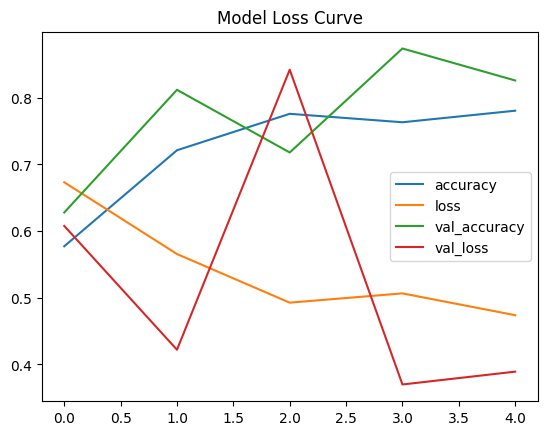

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history_1.history).plot()
plt.title("Model Loss Curve")

---

## Experimenting new model using callback to detect the ideal learning rate

In [11]:
# Model

# build model
callback_cnn_model = tf.keras.models.Sequential([
    # First Conv Block
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding="same",
                           activation="relu", input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Second Conv Block
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Third Conv Block
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Fourth Conv Block
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile model
callback_cnn_model.compile(loss="binary_crossentropy",
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=["accuracy"])

# learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10 **(epoch/20))

# fit model
callback_cnn_history = callback_cnn_model.fit(train_data_augmented,
                    callbacks=[lr_scheduler],
                    epochs=5,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data))

/home/makrious/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5880 - loss: 0.6679 - val_accuracy: 0.6640 - val_loss: 0.6000 - learning_rate: 1.0000e-04
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 949ms/step - accuracy: 0.6947 - loss: 0.5794 - val_accuracy: 0.7120 - val_loss: 0.5393 - learning_rate: 1.1220e-04
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 893ms/step - accuracy: 0.7733 - loss: 0.4976 - val_accuracy: 0.8640 - val_loss: 0.3429 - learning_rate: 1.2589e-04
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7887 - loss: 0.4534 - val_accuracy: 0.8460 - val_loss: 0.3330 - learning_rate: 1.4125e-04
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8093 - loss: 0.4268 - val_accuracy: 0.8740 - val_loss: 0.3095 - learning_rate: 1.5849e-04


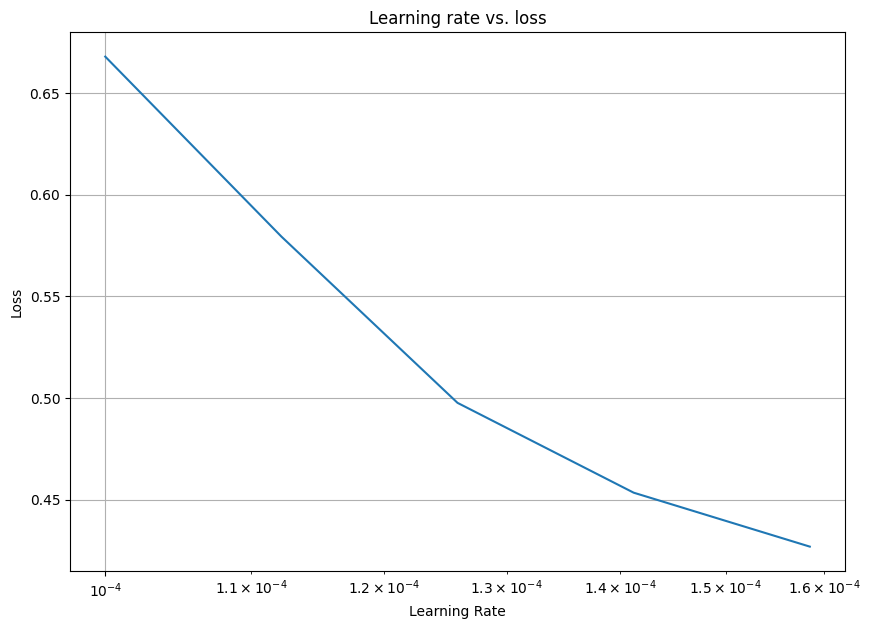

In [12]:
# Plot the learning rate versus the loss
def plot_loss_curve_via_lr(model_history):
    """
    Plot loss vs learning rate using a learning-rate schedule matching the
    number of epochs in model_history.
    """
    losses = model_history.history.get("loss")
    if losses is None:
        raise ValueError("model_history has no 'loss' key")
    n = len(losses)
    lrs = 1e-4 * (10 ** (np.arange(n) / 20))
    plt.figure(figsize=(10, 7))
    plt.semilogx(lrs, losses)
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning rate vs. loss")
    plt.grid(True)
    plt.show()

plot_loss_curve_via_lr(callback_cnn_history)

In [ ]:
import numpy as np

def find_ideal_lr(model_history, skip_begin=10, skip_end=5):
    """
    Find ideal learning rate from model_history.loss by matching the lr array
    length to the number of recorded epochs and returning the lr at the
    steepest descent (after trimming).
    """
    losses = model_history.history.get("loss")
    if losses is None:
        raise ValueError("model_history has no 'loss' key")
    losses = np.array(losses)
    n = len(losses)
    if n <= (skip_begin + skip_end):
        raise ValueError("Not enough epochs for the given skip_begin/skip_end")

    lrs = 1e-4 * (10 ** (np.arange(n) / 20))

    # Smooth losses a bit (use smaller window for short histories)
    window = min(5, n)
    losses_smooth = np.convolve(losses, np.ones(window) / window, mode='same')

    # gradient w.r.t log10(lr)
    log_lrs = np.log10(lrs)
    gradients = np.gradient(losses_smooth, log_lrs)

    # trim unstable regions
    gradients_trim = gradients[skip_begin:-skip_end]
    lrs_trim = lrs[skip_begin:-skip_end]

    ideal_lr = lrs_trim[np.argmin(gradients_trim)]
    return ideal_lr

ideal_lr = find_ideal_lr(model_history=callback_cnn_history)

In [14]:
# Rebuild with the lowest learning rate and enhanced architecture

# Build model with improvements
ideal_cnn_model = tf.keras.models.Sequential([
    # First Conv Block
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding="same",
                           activation="relu", input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Second Conv Block
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Third Conv Block
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Fourth Conv Block
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Fifth Conv Block
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),

    # Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile model with ideal learning rate and additional metrics
ideal_cnn_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=ideal_lr),
    metrics=["accuracy"]
)

# Fit model with more epochs and callbacks
ideal_cnn_history = ideal_cnn_model.fit(
    train_data_augmented,
    epochs=5,
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data),
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5100 - loss: 0.6899 - val_accuracy: 0.6560 - val_loss: 0.6368
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 935ms/step - accuracy: 0.6593 - loss: 0.6209 - val_accuracy: 0.7900 - val_loss: 0.4723
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 999ms/step - accuracy: 0.7653 - loss: 0.5206 - val_accuracy: 0.7780 - val_loss: 0.5804
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7760 - loss: 0.4982 - val_accuracy: 0.8480 - val_loss: 0.3759
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7980 - loss: 0.4431 - val_accuracy: 0.8780 - val_loss: 0.2918


Text(0.5, 1.0, 'Model Loss Curve')

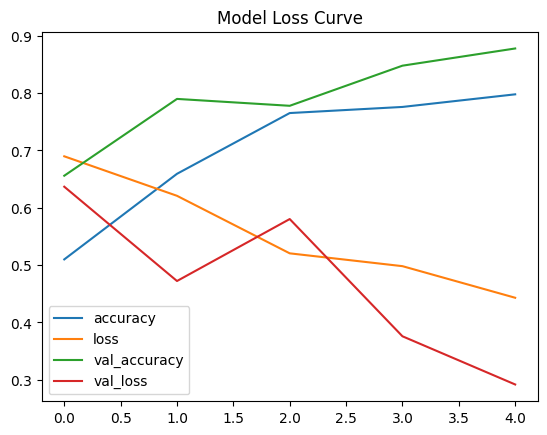

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(ideal_cnn_history.history).plot()
plt.title("Model Loss Curve")

In [16]:
ideal_cnn_model.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 320ms/step - accuracy: 0.8780 - loss: 0.2918


[0.29177165031433105, 0.878000020980835]

---

## Multi-class Image Classification

### Steps

- Become one with the data (visualize, visualize, visualize...)
- Preprocess the data (prepare it for a model)
- Create a model (start with a baseline)
- Fit the model
- Evaluate the model
- Adjust different parameters and improve model (try to beat your baseline)
- Repeat until satisfied

### Ways to improve the Deep Model
- Adding more layers
- Increase number of hidden units
- Change the activation function
- Change the optimization function
- Change the learning rate
- Fitting on more data
- Fitting for longer

In [17]:
# Data
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [18]:
# Classes
import pathlib
import numpy as np
data_dir= pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [19]:
# Preprocess data with augmentation parameters in ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Import data from directories and turn it into batches
train_data_augmented = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    seed=42
)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [20]:
# Create Model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(10, 3, activation="relu",input_shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

hist = model.fit(train_data_augmented,
                 epochs=5,
                 steps_per_epoch=len(train_data_augmented),
                 validation_data=test_data,
                 validation_steps=len(test_data)
)

/home/makrious/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/makrious/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.2005 - loss: 2.1857 - val_accuracy: 0.2500 - val_loss: 2.0633
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 214s 910ms/step - accuracy: 0.2553 - loss: 2.0652 - val_accuracy: 0.3316 - val_loss: 1.9158
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 229s 975ms/step - accuracy: 0.2980 - loss: 1.9861 - val_accuracy: 0.3848 - val_loss: 1.7967
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.3179 - loss: 1.9259 - val_accuracy: 0.3180 - val_loss: 1.9945
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.3389 - loss: 1.9004 - val_accuracy: 0.4108 - val_loss: 1.7566


In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [22]:
# Evaluate Model
model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step - accuracy: 0.4108 - loss: 1.7566


[1.7566049098968506, 0.4108000099658966]

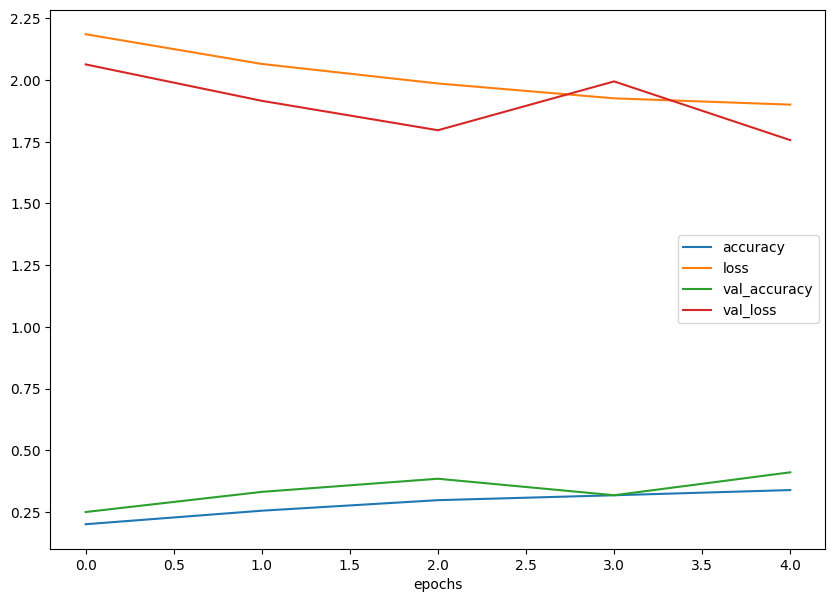

In [23]:
# Plot Curves
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(hist.history).plot(figsize=(10, 7))
plt.xlabel("epochs")
plt.show()

---